In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv(
r"C:\Users\ritik\OneDrive\Pictures\Desktop\Bluestock_mf_capstone\Data\processed\nav_history_clean.csv"
)

performance = pd.read_csv(
r"C:\Users\ritik\OneDrive\Pictures\Desktop\Bluestock_mf_capstone\Data\processed\scheme_performance_clean.csv"
)

fund_master = pd.read_csv(
r"C:\Users\ritik\OneDrive\Pictures\Desktop\Bluestock_mf_capstone\Data\Raw\01_fund_master.csv"
)

### Task 1: Daily Returns


In [9]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
["amfi_code","date"]
)

nav["daily_return"] = nav.groupby(
"amfi_code"
)["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


##### Distribution:

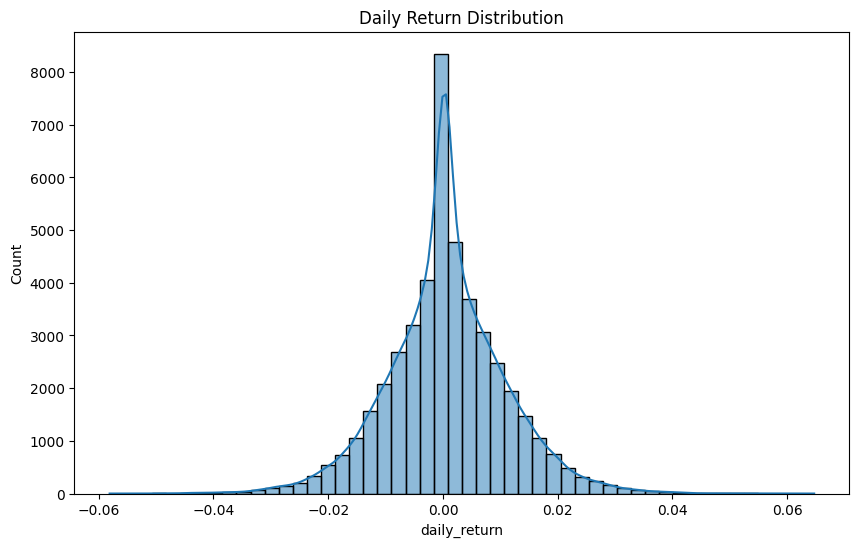

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
nav["daily_return"].dropna(),
bins=50,
kde=True
)

plt.title("Daily Return Distribution")

plt.show()

## Task 2: CAGR

In [10]:
cagr_table = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund]

    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    years = (
        (df["date"].max() -
         df["date"].min()).days
    ) / 365

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

    cagr_table.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
cagr_table,
columns=["amfi_code","cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


## Task 3: Sharpe Ratio

In [11]:
rf = 0.065

sharpe_scores = []

for fund in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    sharpe = (
        (r.mean()*252 - rf)
        /
        (r.std())
    ) * np.sqrt(252)

    sharpe_scores.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
sharpe_scores,
columns=["amfi_code","sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-50.782301
1,100025,-142.907888
2,100033,275.612083
3,101206,258.857759
4,101207,40.990514


## Task 4: Sortino Ratio

In [12]:
sortino_scores = []

for fund in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = r[r < 0]

    sortino = (
        (r.mean()*252 - rf)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_scores.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
sortino_scores,
columns=["amfi_code","sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-88.463960
1,100025,-237.338952
2,100033,460.941758
3,101206,453.489844
4,101207,69.714237


## Task 5: Alpha & Beta

In [14]:
benchmark = nav.groupby(
"date"
)["daily_return"].mean()

In [15]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    merged = pd.merge(
        fund_data,
        benchmark.reset_index(),
        on="date",
        suffixes=(
            "_fund",
            "_benchmark"
        )
    )

    merged = merged.dropna()

    slope, intercept, r, p, se = linregress(
        merged["daily_return_benchmark"],
        merged["daily_return_fund"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append(
        [fund,alpha,beta]
    )

alpha_beta_df = pd.DataFrame(
alpha_beta,
columns=[
"amfi_code",
"alpha",
"beta"
]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


In [16]:
alpha_beta_df.to_csv(
r"C:\Users\ritik\OneDrive\Pictures\Desktop\Bluestock_mf_capstone\Data\processed\alpha_beta.csv",
index=False
)

## Task 6: Maximum Drawdown

In [17]:
drawdowns = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    df["running_max"] = (
        df["nav"].cummax()
    )

    df["drawdown"] = (
        df["nav"] /
        df["running_max"]
        - 1
    )

    drawdowns.append(
        [
            fund,
            df["drawdown"].min()
        ]
    )

dd_df = pd.DataFrame(
drawdowns,
columns=[
"amfi_code",
"max_drawdown"
]
)

## Task 7: Fund Scorecard

In [19]:
scorecard = performance.copy()

scorecard = scorecard.merge(
sharpe_df,
on="amfi_code"
)

scorecard = scorecard.merge(
alpha_beta_df,
on="amfi_code"
)

scorecard = scorecard.merge(
dd_df,
on="amfi_code"
)

In [21]:
print(scorecard.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha_x', 'beta_x', 'sharpe_ratio_x', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'sharpe_ratio_y', 'alpha_y', 'beta_y', 'max_drawdown']


In [22]:
# Merge everything again

scorecard = performance.copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    dd_df,
    on="amfi_code",
    how="left"
)

print(scorecard.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha_x', 'beta_x', 'sharpe_ratio_x',
       'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore',
       'expense_ratio_pct', 'morningstar_rating', 'risk_grade',
       'sharpe_ratio_y', 'alpha_y', 'beta_y', 'max_drawdown'],
      dtype='object')


In [25]:
scorecard["fund_score"] = (

    0.30 * scorecard["return_3yr_pct"].rank(pct=True)

    +

    0.25 * scorecard["sharpe_ratio_y"].rank(pct=True)

    +

    0.20 * scorecard["alpha_y"].rank(pct=True)

    +

    0.15 * (
        1 - scorecard["expense_ratio_pct"].rank(pct=True)
    )

    +

    0.10 * (
        1 - scorecard["max_drawdown"].rank(pct=True)
    )

) * 100

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,sharpe_ratio_y,alpha_y,beta_y,max_drawdown,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,-21.84,979,1.36,3,High,297.385502,0.102647,1.194815,-0.181885,80.625
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,-13.67,23185,1.38,5,High,275.612083,0.114423,0.991590,-0.162172,76.375
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,-19.50,35012,1.45,5,Moderately High,329.299480,0.102645,1.068746,-0.129740,74.125
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,-17.07,11361,1.46,5,Moderate,364.969375,0.181968,0.557134,-0.112657,71.125
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,...,-26.99,37835,1.61,4,High,285.294707,0.087723,1.120482,-0.172481,67.875


In [24]:
print(scorecard.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha_x', 'beta_x', 'sharpe_ratio_x', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'sharpe_ratio_y', 'alpha_y', 'beta_y', 'max_drawdown']


In [26]:
scorecard.to_csv(
r"C:\Users\ritik\OneDrive\Pictures\Desktop\Bluestock_mf_capstone\Data\processed\fund_scorecard.csv",
index=False
)

print("fund_scorecard.csv saved successfully")

fund_scorecard.csv saved successfully


In [27]:
scorecard[
[
"scheme_name",
"fund_score"
]
].head(10)

,scheme_name,fund_score
12,ICICI Pru Midcap Fund - Regular - Growth,80.6250
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,76.3750
22,Kotak Flexicap Fund - Regular - Growth,74.1250
34,Mirae Asset Large Cap Fund - Regular - Growth,71.1250
38,DSP Midcap Fund - Regular - Growth,67.8750
2,SBI Small Cap Fund - Regular Plan - Growth,67.7500
11,ICICI Pru Bluechip Fund - Direct - Growth,67.3750
39,DSP Small Cap Fund - Regular - Growth,63.8125
0,SBI Bluechip Fund - Regular Plan - Growth,61.4375
26,Axis Midcap Fund - Regular - Growth,60.6250


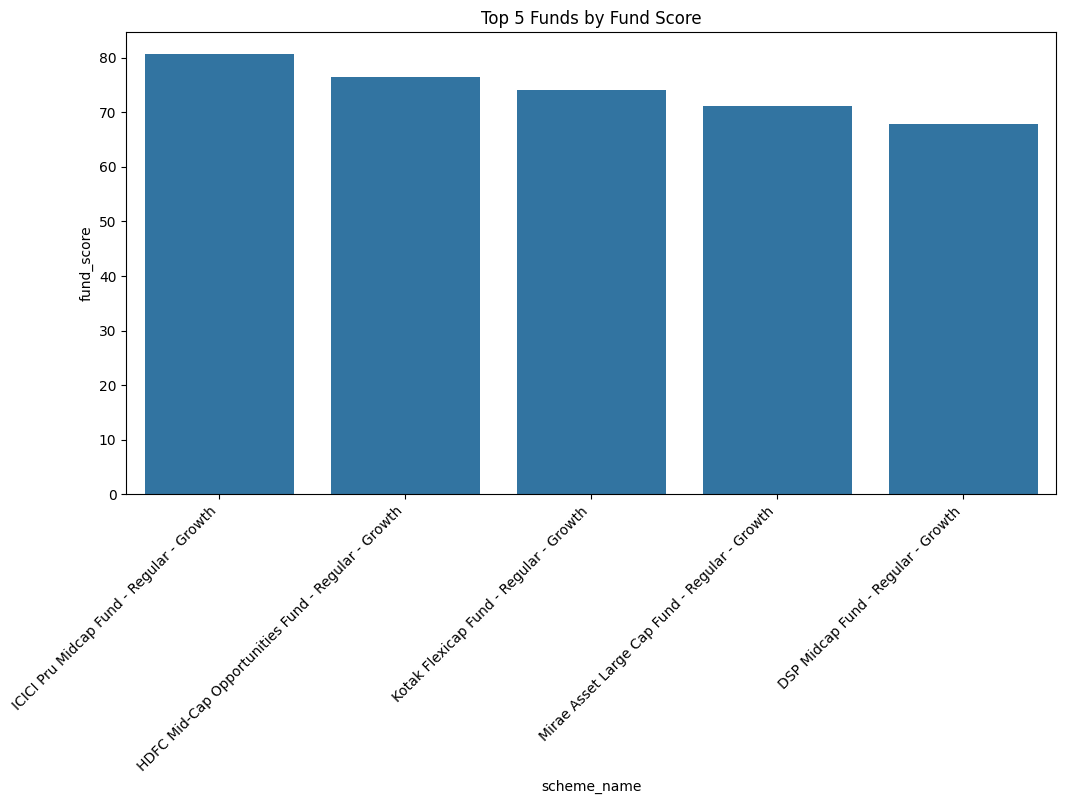

In [28]:
top5 = scorecard.nlargest(
    5,
    "fund_score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top5,
    x="scheme_name",
    y="fund_score"
)

plt.xticks(rotation=45, ha="right")

plt.title("Top 5 Funds by Fund Score")

plt.savefig(
r"C:\Users\ritik\OneDrive\Pictures\Desktop\Bluestock_mf_capstone\reports\charts\benchmark_comparison.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

# Performance Analytics Findings

1. Top-ranked funds achieved superior risk-adjusted returns as reflected by higher Sharpe Ratios.
2. Alpha analysis identified funds consistently outperforming the benchmark.
3. Funds with lower maximum drawdowns demonstrated stronger downside protection.
4. Higher 3-year returns significantly contributed to overall fund rankings.
5. Composite fund scoring enabled objective comparison across multiple performance dimensions.